In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("../data/raw/telecom_churn.csv")

# Shape
print("Shape of dataset:", df.shape)

# Column names
print("\nColumns:")
print(df.columns.tolist())

# Data types
print("\nData Types:")
print(df.dtypes)

# Missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Preview data
df.head()

Shape of dataset: (25000, 36)

Columns:
['customer_id', 'gender', 'age', 'region_circle', 'connection_type', 'plan_type', 'contract_type', 'base_plan_category', 'tenure_months', 'monthly_charges', 'total_charges', 'avg_data_gb_month', 'avg_voice_mins_month', 'sms_count_month', 'overage_charges', 'is_family_plan', 'is_multi_service', 'network_issues_3m', 'dropped_call_rate', 'avg_data_speed_mbps', 'num_complaints_3m', 'num_complaints_12m', 'call_center_interactions_3m', 'last_complaint_resolution_days', 'app_logins_30d', 'selfcare_transactions_30d', 'auto_pay_enrolled', 'late_payment_flag_3m', 'avg_payment_delay_days', 'arpu', 'segment_value', 'nps_score', 'service_rating_last_6m', 'received_competitor_offer_flag', 'retention_offer_accepted_flag', 'is_churn']

Data Types:
customer_id                         int64
gender                             object
age                                 int64
region_circle                      object
connection_type                    object
plan_typ

,customer_id,gender,age,region_circle,connection_type,plan_type,contract_type,base_plan_category,tenure_months,monthly_charges,...,auto_pay_enrolled,late_payment_flag_3m,avg_payment_delay_days,arpu,segment_value,nps_score,service_rating_last_6m,received_competitor_offer_flag,retention_offer_accepted_flag,is_churn
0,100000,Female,23,West,4G,Postpaid,2 Year,Postpaid Platinum,84,1133.57,...,0,0,0.4,1133.57,High,13.0,3.2,0,0,0
1,100001,Male,72,West,4G,Prepaid,No Contract,Prepaid Unlimited,32,683.24,...,0,1,5.4,688.54,Medium,41.0,3.6,0,0,0
2,100002,Female,47,South,4G,Prepaid,No Contract,Prepaid Regular,119,307.04,...,1,0,0.0,307.05,Low,53.0,5.0,0,0,0
3,100003,Female,74,West,4G,Prepaid,No Contract,Prepaid Mini,73,213.82,...,1,0,0.0,214.89,Low,20.0,4.5,1,1,0
4,100004,Male,41,South,5G,Prepaid,No Contract,Prepaid Regular,92,383.17,...,0,0,0.5,383.99,Low,17.0,2.6,0,0,0


In [3]:
# 1. Check if customer_id is unique
print("Duplicate customer_id count:", df["customer_id"].duplicated().sum())

# 2. Check target column distribution
print("\nTarget column distribution:")
print(df["is_churn"].value_counts())

# 3. Check churn percentage
print("\nChurn percentage:")
print(df["is_churn"].value_counts(normalize=True) * 100)

Duplicate customer_id count: 0

Target column distribution:
is_churn
0    14643
1    10357
Name: count, dtype: int64

Churn percentage:
is_churn
0    58.572
1    41.428
Name: proportion, dtype: float64


In [4]:
# Check missing values properly
missing = df.isnull().sum()
missing = missing[missing > 0]
print("Columns with missing values:")
print(missing)

# Basic statistics for numerical columns
print("\nNumerical Summary:")
print(df.describe())

# Check categorical columns unique values
categorical_cols = df.select_dtypes(include="object").columns

for col in categorical_cols:
    print(f"\nUnique values in {col}:")
    print(df[col].unique())

Columns with missing values:
Series([], dtype: int64)

Numerical Summary:
         customer_id           age  tenure_months  monthly_charges  \
count   25000.000000  25000.000000   25000.000000     25000.000000   
mean   112499.500000     45.960200      60.149600       475.518315   
std      7217.022701     16.401422      34.374772       267.550787   
min    100000.000000     18.000000       1.000000        99.000000   
25%    106249.750000     32.000000      31.000000       300.607500   
50%    112499.500000     46.000000      60.000000       385.735000   
75%    118749.250000     60.000000      90.000000       601.250000   
max    124999.000000     74.000000     119.000000      1603.490000   

       total_charges  avg_data_gb_month  avg_voice_mins_month  \
count   25000.000000       25000.000000          25000.000000   
mean    27230.695507          25.107675            602.187920   
std     23717.163861           9.907997            247.929808   
min       159.030000           0.50

In [5]:
# Drop ID column
df = df.drop(columns=["customer_id"])

print("Updated shape:", df.shape)

Updated shape: (25000, 35)


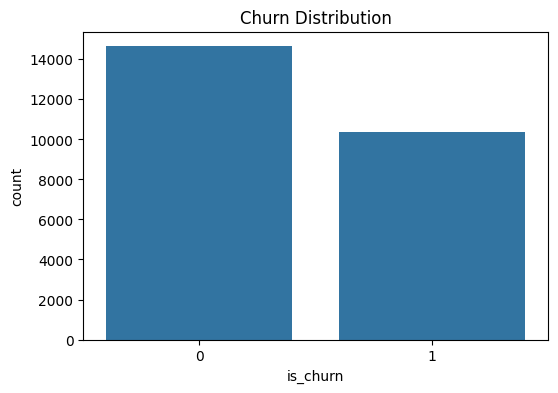

In [6]:
# Set style
plt.figure(figsize=(6,4))
sns.countplot(x="is_churn", data=df)
plt.title("Churn Distribution")
plt.show()

In [7]:
# Compare numerical features by churn
num_cols = df.select_dtypes(include=["int64", "float64"]).columns
num_cols = num_cols.drop("is_churn")

for col in num_cols:
    print(f"\nAverage {col} by churn:")
    print(df.groupby("is_churn")[col].mean())


Average age by churn:
is_churn
0    46.046985
1    45.837501
Name: age, dtype: float64

Average tenure_months by churn:
is_churn
0    62.161989
1    57.304432
Name: tenure_months, dtype: float64

Average monthly_charges by churn:
is_churn
0    495.945267
1    446.638151
Name: monthly_charges, dtype: float64

Average total_charges by churn:
is_churn
0    29309.468911
1    24291.670794
Name: total_charges, dtype: float64

Average avg_data_gb_month by churn:
is_churn
0    25.120144
1    25.090046
Name: avg_data_gb_month, dtype: float64

Average avg_voice_mins_month by churn:
is_churn
0    600.680325
1    604.319398
Name: avg_voice_mins_month, dtype: float64

Average sms_count_month by churn:
is_churn
0    50.673632
1    50.623636
Name: sms_count_month, dtype: float64

Average overage_charges by churn:
is_churn
0    55.551885
1    54.724964
Name: overage_charges, dtype: float64

Average is_family_plan by churn:
is_churn
0    0.248856
1    0.248528
Name: is_family_plan, dtype: float64

Ave

In [8]:
cat_cols = df.select_dtypes(include="object").columns

for col in cat_cols:
    print(f"\nChurn rate by {col}:")
    print(df.groupby(col)["is_churn"].mean())


Churn rate by gender:
gender
Female    0.413753
Male      0.417504
Other     0.381818
Name: is_churn, dtype: float64

Churn rate by region_circle:
region_circle
East     0.415902
Metro    0.421689
North    0.409795
South    0.409699
West     0.415547
Name: is_churn, dtype: float64

Churn rate by connection_type:
connection_type
4G                      0.410609
5G                      0.415700
Fiber Home Broadband    0.421370
Name: is_churn, dtype: float64

Churn rate by plan_type:
plan_type
Postpaid    0.314121
Prepaid     0.457025
Name: is_churn, dtype: float64

Churn rate by contract_type:
contract_type
1 Year            0.312063
2 Year            0.233154
Month-to-Month    0.328176
No Contract       0.457025
Name: is_churn, dtype: float64

Churn rate by base_plan_category:
base_plan_category
Postpaid Gold        0.312104
Postpaid Platinum    0.305040
Postpaid Silver      0.320767
Prepaid Mini         0.458310
Prepaid Regular      0.448315
Prepaid Unlimited    0.476870
Name: is_chur

In [9]:
X = df.drop(columns=["is_churn"])
y = df["is_churn"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (25000, 34)
Target shape: (25000,)


In [10]:
num_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = X.select_dtypes(include=["object"]).columns.tolist()

print("Number of numerical columns:", len(num_cols))
print("Number of categorical columns:", len(cat_cols))

print("\nNumerical Columns:")
print(num_cols)

print("\nCategorical Columns:")
print(cat_cols)

Number of numerical columns: 27
Number of categorical columns: 7

Numerical Columns:
['age', 'tenure_months', 'monthly_charges', 'total_charges', 'avg_data_gb_month', 'avg_voice_mins_month', 'sms_count_month', 'overage_charges', 'is_family_plan', 'is_multi_service', 'network_issues_3m', 'dropped_call_rate', 'avg_data_speed_mbps', 'num_complaints_3m', 'num_complaints_12m', 'call_center_interactions_3m', 'last_complaint_resolution_days', 'app_logins_30d', 'selfcare_transactions_30d', 'auto_pay_enrolled', 'late_payment_flag_3m', 'avg_payment_delay_days', 'arpu', 'nps_score', 'service_rating_last_6m', 'received_competitor_offer_flag', 'retention_offer_accepted_flag']

Categorical Columns:
['gender', 'region_circle', 'connection_type', 'plan_type', 'contract_type', 'base_plan_category', 'segment_value']


In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (20000, 34)
X_test shape: (5000, 34)


In [12]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# Preprocessing for numerical data
num_transformer = StandardScaler()

# Preprocessing for categorical data
cat_transformer = OneHotEncoder(handle_unknown="ignore")

# Combine preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_transformer, num_cols),
        ("cat", cat_transformer, cat_cols)
    ]
)

# Create full pipeline
model = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

In [13]:
# Train model
model.fit(X_train, y_train)

print("Model training completed.")

Model training completed.


In [14]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Predictions
y_pred = model.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.6344

Confusion Matrix:
[[2440  489]
 [1339  732]]

Classification Report:
              precision    recall  f1-score   support

           0       0.65      0.83      0.73      2929
           1       0.60      0.35      0.44      2071

    accuracy                           0.63      5000
   macro avg       0.62      0.59      0.59      5000
weighted avg       0.63      0.63      0.61      5000



In [15]:

# Get probabilities
y_probs = model.predict_proba(X_test)[:, 1]

# Set new threshold
threshold = 0.35

y_pred_adjusted = (y_probs >= threshold).astype(int)

from sklearn.metrics import classification_report

print("Classification Report with threshold =", threshold)
print(classification_report(y_test, y_pred_adjusted))

Classification Report with threshold = 0.35
              precision    recall  f1-score   support

           0       0.71      0.41      0.52      2929
           1       0.48      0.76      0.59      2071

    accuracy                           0.56      5000
   macro avg       0.60      0.59      0.56      5000
weighted avg       0.62      0.56      0.55      5000



In [16]:
from sklearn.metrics import roc_auc_score

roc_score = roc_auc_score(y_test, y_probs)
print("ROC-AUC Score:", roc_score)

ROC-AUC Score: 0.6507752525198406


In [17]:
from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight="balanced"
    ))
])

# Train
rf_model.fit(X_train, y_train)

# Predict probabilities
rf_probs = rf_model.predict_proba(X_test)[:, 1]

# Default threshold evaluation
rf_pred = rf_model.predict(X_test)

from sklearn.metrics import classification_report, roc_auc_score

print("Random Forest Classification Report:\n")
print(classification_report(y_test, rf_pred))

print("Random Forest ROC-AUC:", roc_auc_score(y_test, rf_probs))

Random Forest Classification Report:

              precision    recall  f1-score   support

           0       0.64      0.82      0.72      2929
           1       0.57      0.35      0.43      2071

    accuracy                           0.62      5000
   macro avg       0.61      0.58      0.57      5000
weighted avg       0.61      0.62      0.60      5000

Random Forest ROC-AUC: 0.6336425946828854


In [18]:
import pandas as pd

# Extract feature names after preprocessing
feature_names = (
    num_cols +
    list(model.named_steps["preprocessing"]
         .named_transformers_["cat"]
         .get_feature_names_out(cat_cols))
)

# Get coefficients
coefficients = model.named_steps["classifier"].coef_[0]

# Create dataframe
coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

# Sort by absolute impact
coef_df["Abs_Coefficient"] = coef_df["Coefficient"].abs()
coef_df = coef_df.sort_values(by="Abs_Coefficient", ascending=False)

coef_df.head(15)

,Feature,Coefficient,Abs_Coefficient
22,arpu,2.410402,2.410402
2,monthly_charges,-2.393846,2.393846
41,contract_type_2 Year,-0.387818,0.387818
38,plan_type_Postpaid,-0.297778,0.297778
23,nps_score,-0.204435,0.204435
24,service_rating_last_6m,-0.190644,0.190644
25,received_competitor_offer_flag,0.185988,0.185988
29,gender_Other,-0.160231,0.160231
10,network_issues_3m,0.159877,0.159877
45,base_plan_category_Postpaid Platinum,-0.155254,0.155254


In [19]:
from xgboost import XGBClassifier

xgb_model = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("classifier", XGBClassifier(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric="logloss",
        use_label_encoder=False
    ))
])

# Train
xgb_model.fit(X_train, y_train)

# Predict probabilities
xgb_probs = xgb_model.predict_proba(X_test)[:, 1]

# Default predictions
xgb_pred = xgb_model.predict(X_test)

from sklearn.metrics import classification_report, roc_auc_score

print("XGBoost Classification Report:\n")
print(classification_report(y_test, xgb_pred))

print("XGBoost ROC-AUC:", roc_auc_score(y_test, xgb_probs))

c:\Users\akash\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:200: UserWarning: [20:06:33] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Classification Report:

              precision    recall  f1-score   support

           0       0.64      0.78      0.71      2929
           1       0.56      0.39      0.46      2071

    accuracy                           0.62      5000
   macro avg       0.60      0.59      0.58      5000
weighted avg       0.61      0.62      0.60      5000

XGBoost ROC-AUC: 0.6319914954914796


In [20]:
# Create tenure bucket
df["tenure_bucket"] = pd.cut(
    df["tenure_months"],
    bins=[0, 12, 36, 60, 120],
    labels=["0-1yr", "1-3yr", "3-5yr", "5yr+"]
)

In [21]:
df["complaint_intensity"] = (
    df["num_complaints_3m"] * 2 +
    df["num_complaints_12m"]
)

In [22]:
df["payment_risk_score"] = (
    df["late_payment_flag_3m"] * 2 +
    df["avg_payment_delay_days"]
)

In [23]:
df["engagement_score"] = (
    df["app_logins_30d"] +
    df["selfcare_transactions_30d"]
)

In [24]:
df["bill_shock_flag"] = (df["overage_charges"] > df["overage_charges"].median()).astype(int)

In [25]:
# Redefine features and target after feature engineering
X = df.drop(columns=["is_churn"])
y = df["is_churn"]

print("New X shape:", X.shape)

New X shape: (25000, 39)


In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)

X_train shape: (20000, 39)


In [27]:
num_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()

print("Numerical columns:", len(num_cols))
print("Categorical columns:", len(cat_cols))

Numerical columns: 31
Categorical columns: 8


In [28]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

num_transformer = StandardScaler()
cat_transformer = OneHotEncoder(handle_unknown="ignore")

preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_transformer, num_cols),
        ("cat", cat_transformer, cat_cols)
    ]
)

model = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

In [29]:
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transform

In [30]:
from sklearn.metrics import classification_report, roc_auc_score

y_probs = model.predict_proba(X_test)[:, 1]
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))
print("New ROC-AUC:", roc_auc_score(y_test, y_probs))

              precision    recall  f1-score   support

           0       0.65      0.83      0.73      2929
           1       0.60      0.36      0.45      2071

    accuracy                           0.64      5000
   macro avg       0.62      0.59      0.59      5000
weighted avg       0.63      0.64      0.61      5000

New ROC-AUC: 0.6540012881722411


In [31]:
threshold = 0.35

y_pred_adjusted = (y_probs >= threshold).astype(int)

print("Classification Report with threshold =", threshold)
print(classification_report(y_test, y_pred_adjusted))

Classification Report with threshold = 0.35
              precision    recall  f1-score   support

           0       0.72      0.43      0.54      2929
           1       0.49      0.76      0.59      2071

    accuracy                           0.57      5000
   macro avg       0.60      0.59      0.56      5000
weighted avg       0.62      0.57      0.56      5000

